<a href="https://colab.research.google.com/github/Cristobal2506/ProyectoMineriaDeDatos/blob/main/Prueba1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPACTO DE LA IA EN LA PRODUCTIVIDAD EN LOS TRABAJOS
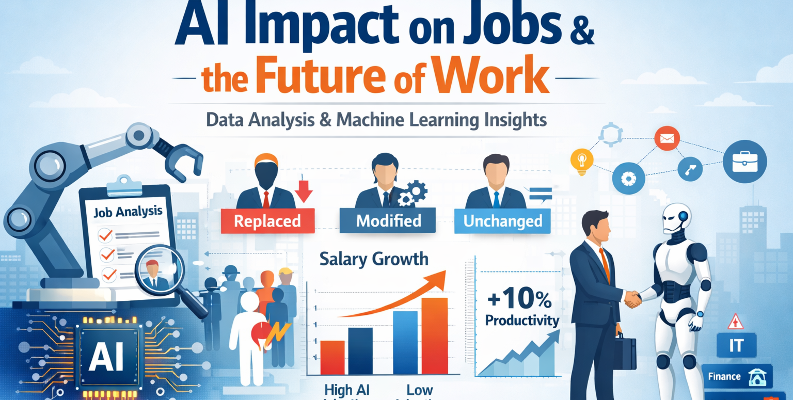

Contexto:
Contexto:En la actualidad, la IA está cambiando la forma en la que se realizan muchas tareas en distintos tipos de trabajos. Gracias a avances tecnologicos como el Aprendizaje automatico, las maquinas pueden realizar actividades que antes solo hacian las personas, especialmente aquellas repetitivas o predecibles.

Esto ha generado consecuencias importantes en el empleo. Algunos trabajaos han sido reemplazados o modificados debido a a la automatización. Por otro lado, han surgido nuevas oportunidades laborales relacionadas con el desarrollo, uso y mantenimiento de estas mismas tecnologias.
En este contexto, analizar la informacion disponible permite comprender mejor estos cambios y anticipar como podrían evolucionar los trabajos en un futuro, ayudando a las personas y organizaciones a prepararse.


link dataset
https://www.kaggle.com/datasets/sumeakash/ai-impact-on-job-sector

In [10]:
#importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [11]:
#importar el dataset
df = pd.read_csv("/content/ai_job_impact.csv")

In [12]:
#indentificamos las columnas
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry',
       'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk',
       'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI',
       'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction',
       'Productivity_Change_%'],
      dtype='object')

In [13]:
df.head(2001
        )

,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31


### Codificación de variables categóricas

Vamos a aplicar la técnica de one-hot encoding a las columnas 'Industry' y 'Job_Role' para convertirlas en un formato numérico que los modelos de machine learning puedan interpretar.

In [38]:
# Aplicar One-Hot Encoding a las columnas 'Industry' y 'Job_Role'
df_encoded = pd.get_dummies(df, columns=['Industry', 'Job_Role'], drop_first=True)

print('Primeras 5 filas del DataFrame con columnas codificadas:')
display(df_encoded.head())

Primeras 5 filas del DataFrame con columnas codificadas:


,Employee_ID,Age,Gender,Education_Level,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,...,Job_Role_Nurse,Job_Role_Professor,Job_Role_Quality Inspector,Job_Role_SEO Specialist,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supervisor,Job_Role_Teacher,Job_Role_Technician
0,E0001,50,Female,Bachelor,26,High,High,Yes,106820,95455,...,False,False,False,False,False,False,False,False,False,False
1,E0002,45,Male,High School,19,Low,Low,Yes,74131,72013,...,False,False,True,False,False,False,False,False,False,False
2,E0003,51,Female,Master,28,Medium,Medium,Yes,35311,42290,...,False,False,False,False,False,False,False,False,False,False
3,E0004,48,Male,PhD,24,Medium,Medium,Yes,114478,107820,...,False,False,False,False,False,False,False,False,True,False
4,E0005,24,Male,Bachelor,0,High,Medium,No,33890,40945,...,False,False,False,False,False,False,False,False,False,False


In [14]:
#Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '-', df[feature].isna().sum())

Total de valores nulos de Employee_ID - 0
Total de valores nulos de Age - 0
Total de valores nulos de Gender - 0
Total de valores nulos de Education_Level - 0
Total de valores nulos de Industry - 0
Total de valores nulos de Job_Role - 0
Total de valores nulos de Years_Experience - 0
Total de valores nulos de AI_Adoption_Level - 0
Total de valores nulos de Automation_Risk - 0
Total de valores nulos de Upskilling_Required - 0
Total de valores nulos de Salary_Before_AI - 0
Total de valores nulos de Salary_After_AI - 0
Total de valores nulos de Job_Status - 0
Total de valores nulos de Work_Hours_Per_Week - 0
Total de valores nulos de Remote_Work - 0
Total de valores nulos de Job_Satisfaction - 0
Total de valores nulos de Productivity_Change_% - 0


como no hay valores nulos, continuamos


In [15]:
df.shape   #numero de filas y columnas validas

(2000, 17)

In [16]:
df['Industry'].value_counts()

,count
Industry,
Finance,300
IT,298
Manufacturing,295
Education,293
Marketing,273
Retail,271
Healthcare,270


In [17]:
#Selecciona solo las caracteristicas que se van a considerar en los posteriores analisis
X = df.iloc[:,[4,5,10,11,16]].values
#La ultima columna(Productivity_Change_%) se separa del resto para analizar la relacion que tiene ella con el resto
Y = df.iloc[:,-1].values

In [18]:
pd.DataFrame(X).head(10)

,0,1,2,3,4
0,Marketing,Content Creator,106820,95455,-10.64
1,Manufacturing,Quality Inspector,74131,72013,19.05
2,IT,DevOps Engineer,35311,42290,17.05
3,Education,Teacher,114478,107820,-2.47
4,Healthcare,Doctor,33890,40945,7.03
5,Healthcare,Technician,103969,104781,-19.04
6,Education,Administrator,78555,86183,-17.94
7,Finance,Auditor,99479,105776,5.51
8,Education,Professor,102409,104197,3.71
9,Healthcare,Nurse,31016,42699,30.67


In [19]:
pd.DataFrame(Y).head(10)

,0
0,-10.64
1,19.05
2,17.05
3,-2.47
4,7.03
5,-19.04
6,-17.94
7,5.51
8,3.71
9,30.67


MATRIZ DE CORRELACION

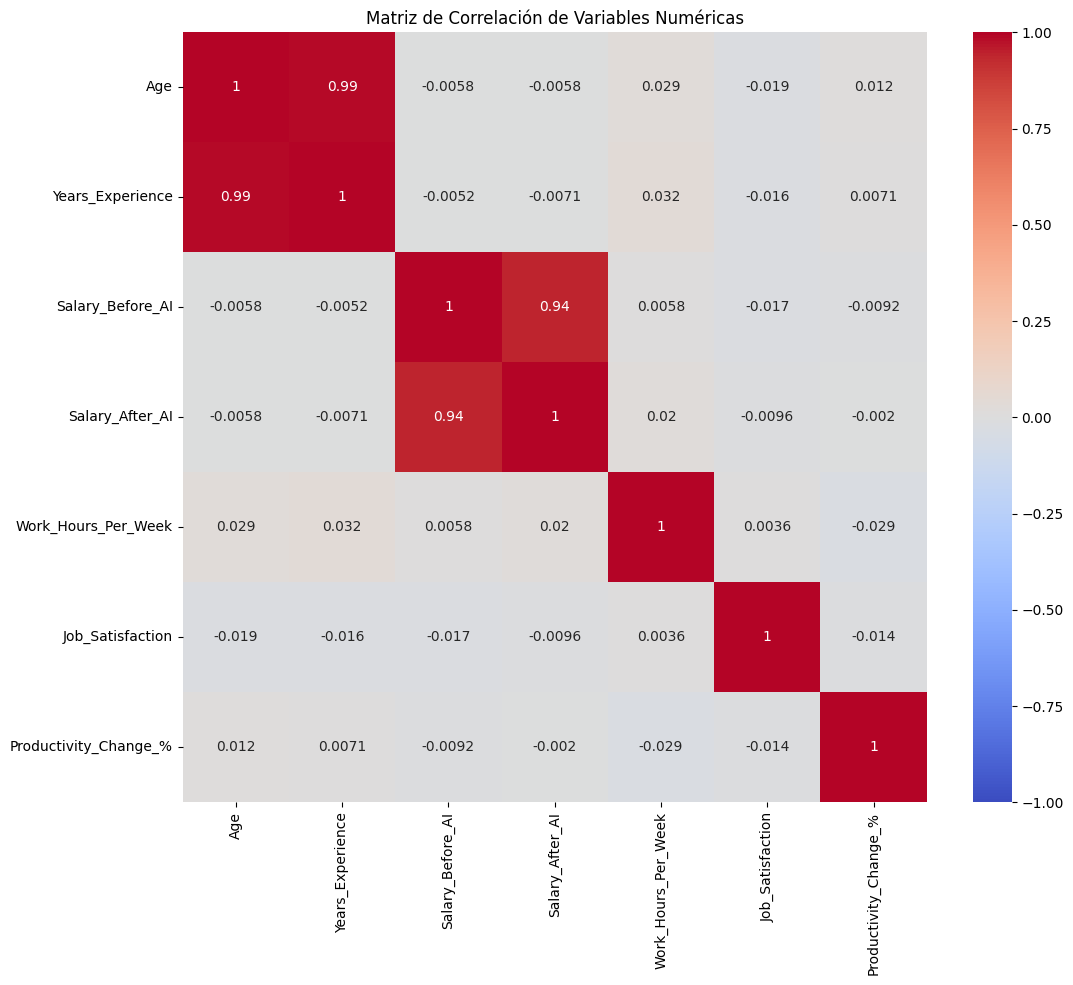

In [20]:
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

#### Observaciones de la Matriz de Correlación:
*   Las variables 'Age' y 'Years_Experience' muestran una correlación positiva muy alta, cercana a 1, lo cual es lógico.
*   'Salary_Before_AI' y 'Salary_After_AI' también tienen una alta correlación positiva, indicando que el salario tiende a mantenerse en un rango similar antes y después de la IA, aunque con cambios.
*   La 'Productivity_Change_%' y 'Salary_Change' también muestran una correlación positiva, aunque moderada, lo que sugiere que un aumento en la productividad puede estar relacionado con un cambio salarial positivo.

### Productividad promedio por industria

/tmp/ipykernel_2714/1527003714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Productivity_Change_%', data=df, estimator=np.mean, palette='viridis')


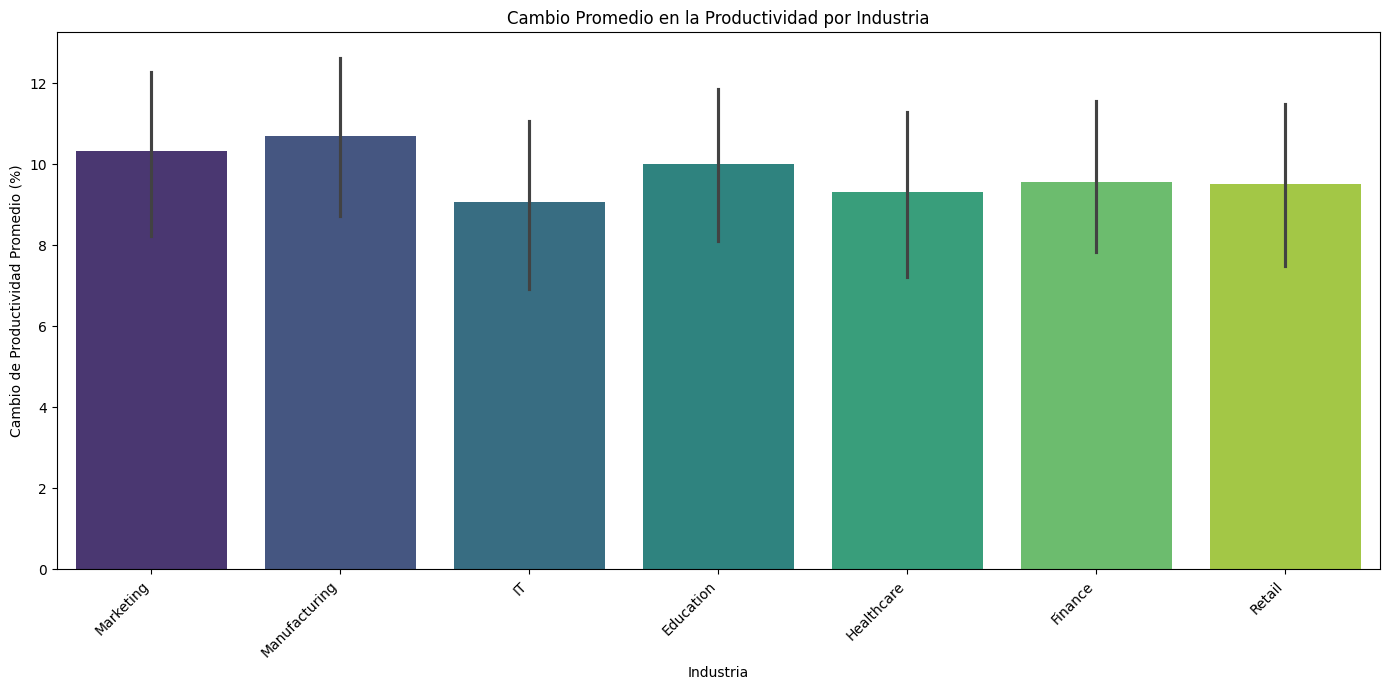

In [21]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='Productivity_Change_%', data=df, estimator=np.mean, palette='viridis')
plt.title('Cambio Promedio en la Productividad por Industria')
plt.xlabel('Industria')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras visualiza el cambio promedio en la productividad en cada industria. Permite identificar qué sectores han experimentado un mayor o menor aumento de productividad tras la adopción de la IA.
*   Podemos observar que la industria de Healthcare muestra un cambio de productividad promedio negativo, mientras que la de IT y Marketing muestran un cambio positivo.

### 1. Impacto de la IA en el Salario

In [22]:
# Calcular el cambio salarial
df['Salary_Change'] = df['Salary_After_AI'] - df['Salary_Before_AI']

print('Primeras 5 filas con la nueva columna Salary_Change:')
display(df[['Salary_Before_AI', 'Salary_After_AI', 'Salary_Change']].head())

Primeras 5 filas con la nueva columna Salary_Change:


,Salary_Before_AI,Salary_After_AI,Salary_Change
0,106820,95455,-11365
1,74131,72013,-2118
2,35311,42290,6979
3,114478,107820,-6658
4,33890,40945,7055


#### Cambio salarial promedio por Industria

/tmp/ipykernel_2714/3635307509.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Industry', y='Salary_Change', data=df, estimator=np.mean, palette='coolwarm')


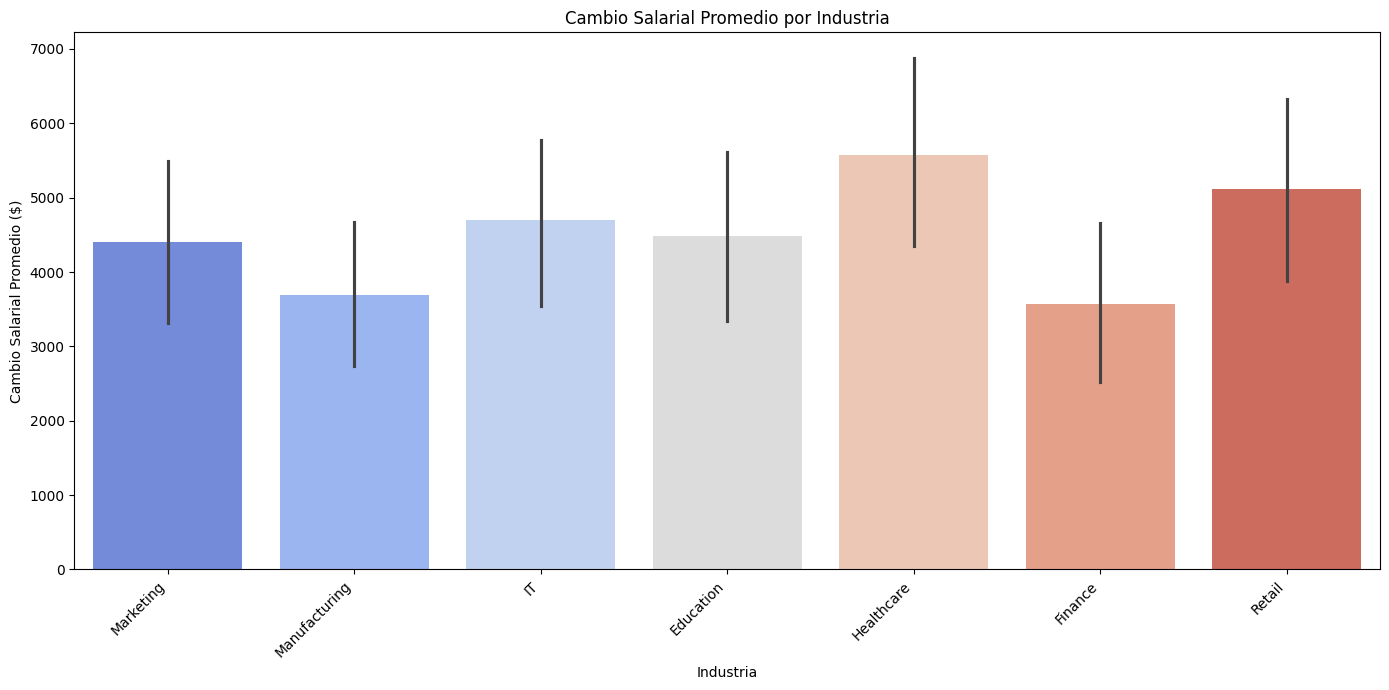

In [23]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Industry', y='Salary_Change', data=df, estimator=np.mean, palette='coolwarm')
plt.title('Cambio Salarial Promedio por Industria')
plt.xlabel('Industria')
plt.ylabel('Cambio Salarial Promedio ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico muestra el cambio salarial promedio por industria. Podemos identificar qué industrias han visto un aumento o disminución más significativo en los salarios después de la introducción de la IA.
*   Por ejemplo, las industrias de 'IT' y 'Finance' parecen tener un aumento salarial promedio, mientras que 'Healthcare' y 'Manufacturing' tienen un cambio salarial promedio negativo.

#### Cambio salarial promedio por Estado del Empleo (`Job_Status`)

/tmp/ipykernel_2714/1824065246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Job_Status', y='Salary_Change', data=df, estimator=np.mean, palette='viridis')


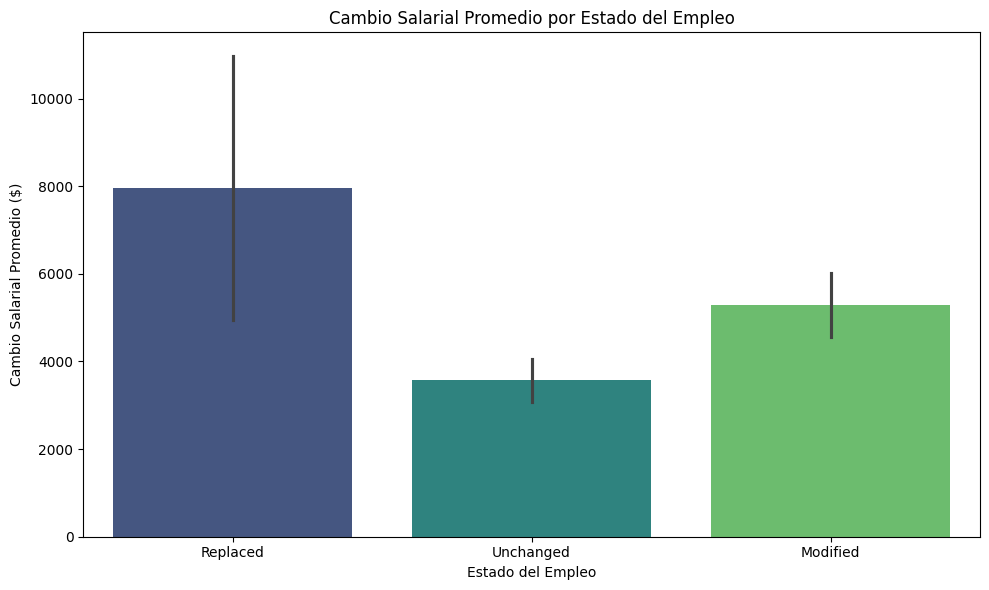

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Job_Status', y='Salary_Change', data=df, estimator=np.mean, palette='viridis')
plt.title('Cambio Salarial Promedio por Estado del Empleo')
plt.xlabel('Estado del Empleo')
plt.ylabel('Cambio Salarial Promedio ($)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras ilustra cómo el estado del empleo (Replaced, Unchanged, Modified) se relaciona con el cambio salarial promedio.
*   Podemos observar que los empleos 'Replaced' (reemplazados) muestran una disminución significativa en el salario, mientras que los empleos 'Modified' (modificados) y 'Unchanged' (sin cambios) muestran un aumento.

### 2. Factores que influyen en el Cambio de Productividad

#### Correlación de `Productivity_Change_%` con variables numéricas

In [25]:
print('Correlación de Productivity_Change_% con otras variables numéricas:')
display(correlation_matrix['Productivity_Change_%'].sort_values(ascending=False))

Correlación de Productivity_Change_% con otras variables numéricas:


,Productivity_Change_%
Productivity_Change_%,1.000000
Age,0.011811
Years_Experience,0.007052
Salary_After_AI,-0.002046
Salary_Before_AI,-0.009214
Job_Satisfaction,-0.014112
Work_Hours_Per_Week,-0.028575


#### Cambio Promedio de Productividad por Nivel de Adopción de IA (`AI_Adoption_Level`)

/tmp/ipykernel_2714/259596549.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AI_Adoption_Level', y='Productivity_Change_%', data=df, estimator=np.mean, palette='plasma')


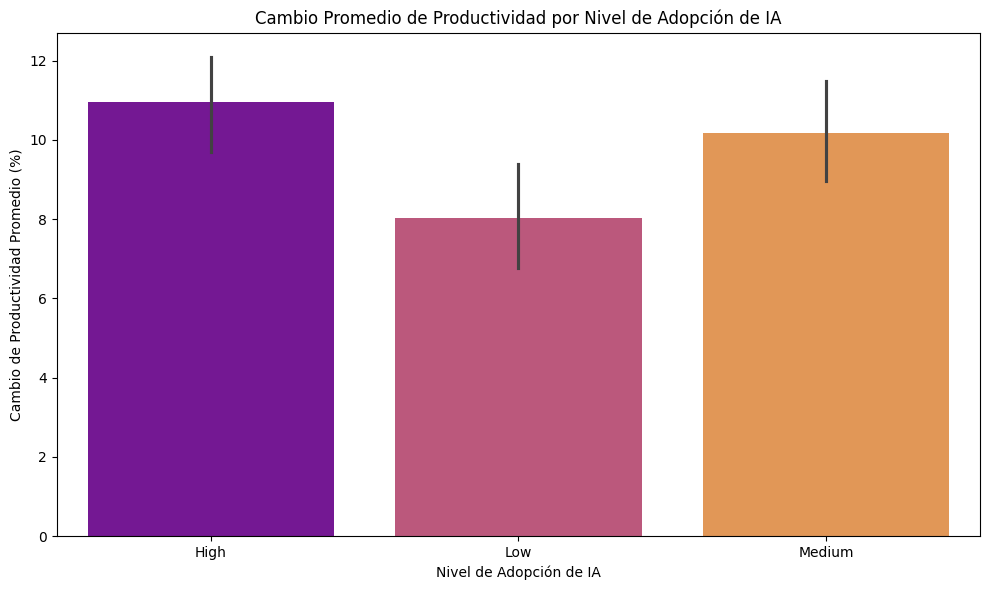

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='AI_Adoption_Level', y='Productivity_Change_%', data=df, estimator=np.mean, palette='plasma')
plt.title('Cambio Promedio de Productividad por Nivel de Adopción de IA')
plt.xlabel('Nivel de Adopción de IA')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras compara el cambio promedio de productividad para diferentes niveles de adopción de IA.
*   Podemos inferir si un mayor nivel de adopción de IA está asociado con un mayor o menor cambio en la productividad. Generalmente, un nivel de adopción 'High' (alto) se correlaciona con un mayor cambio de productividad.

#### Cambio Promedio de Productividad por Satisfacción Laboral (`Job_Satisfaction`)

/tmp/ipykernel_2714/2159459922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Job_Satisfaction', y='Productivity_Change_%', data=df, estimator=np.mean, palette='mako')


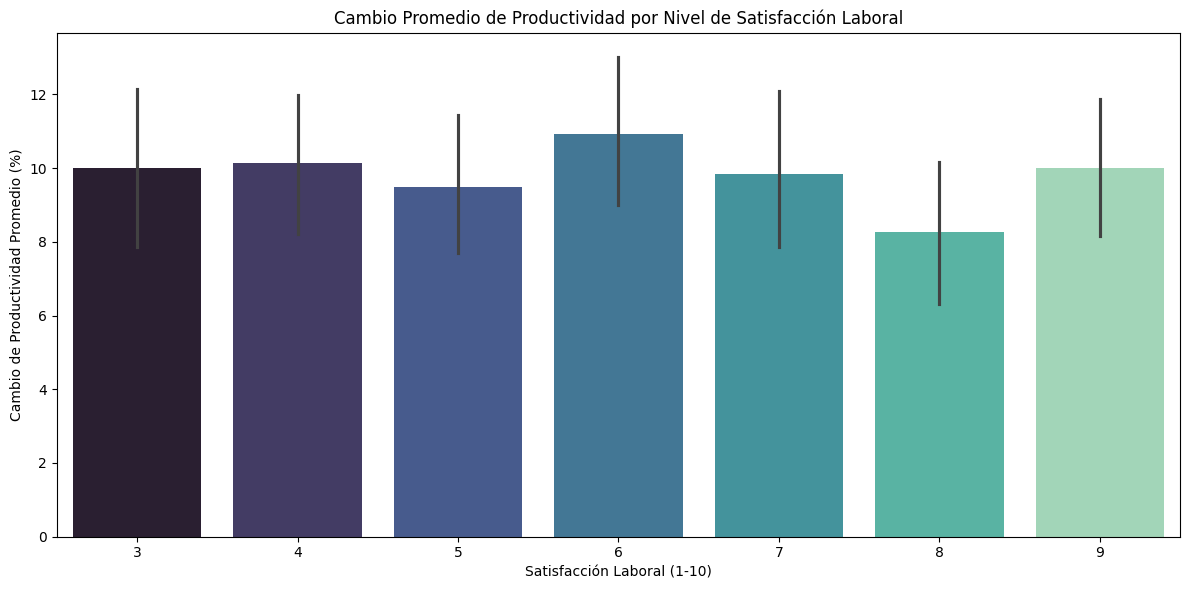

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Job_Satisfaction', y='Productivity_Change_%', data=df, estimator=np.mean, palette='mako')
plt.title('Cambio Promedio de Productividad por Nivel de Satisfacción Laboral')
plt.xlabel('Satisfacción Laboral (1-10)')
plt.ylabel('Cambio de Productividad Promedio (%)')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras muestra el cambio promedio de productividad en relación con los niveles de satisfacción laboral.
*   Nos ayuda a entender si los empleados más satisfechos experimentan mayores aumentos de productividad, o si hay una relación más compleja.

### 3. Estado del Empleo (`Job_Status`) y Riesgo de Automatización (`Automation_Risk`)

#### Distribución del Estado del Empleo por Nivel de Riesgo de Automatización

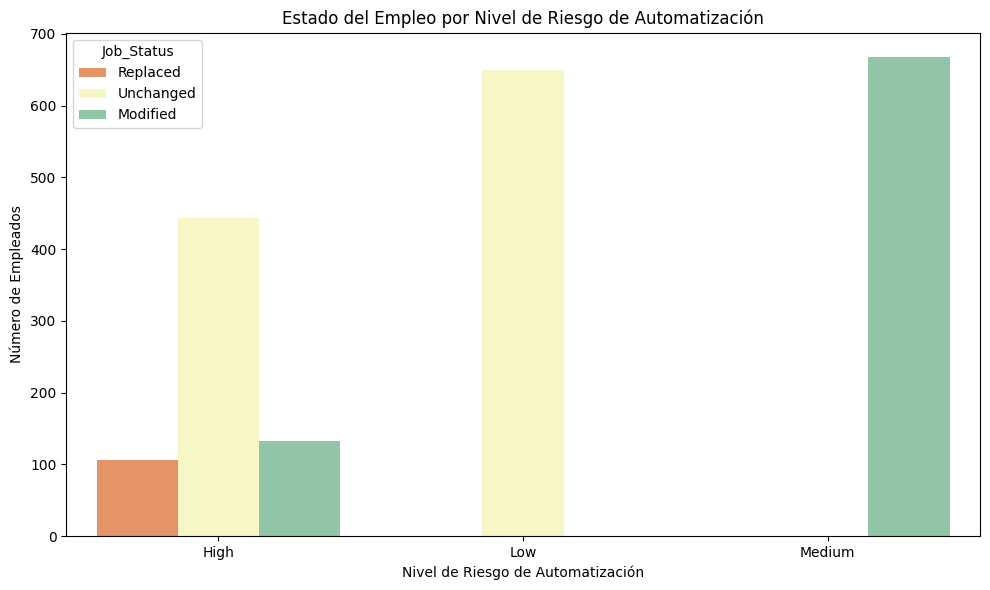

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Automation_Risk', hue='Job_Status', data=df, palette='Spectral')
plt.title('Estado del Empleo por Nivel de Riesgo de Automatización')
plt.xlabel('Nivel de Riesgo de Automatización')
plt.ylabel('Número de Empleados')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras agrupadas muestra la distribución de los estados del empleo (Replaced, Modified, Unchanged) en función del nivel de riesgo de automatización (Low, Medium, High).
*   Podemos observar que los roles con 'High' (alto) riesgo de automatización tienen una mayor proporción de empleados 'Replaced' (reemplazados), mientras que los de 'Low' (bajo) riesgo tienen más empleos 'Unchanged' (sin cambios).

#### Distribución del Estado del Empleo por Industria

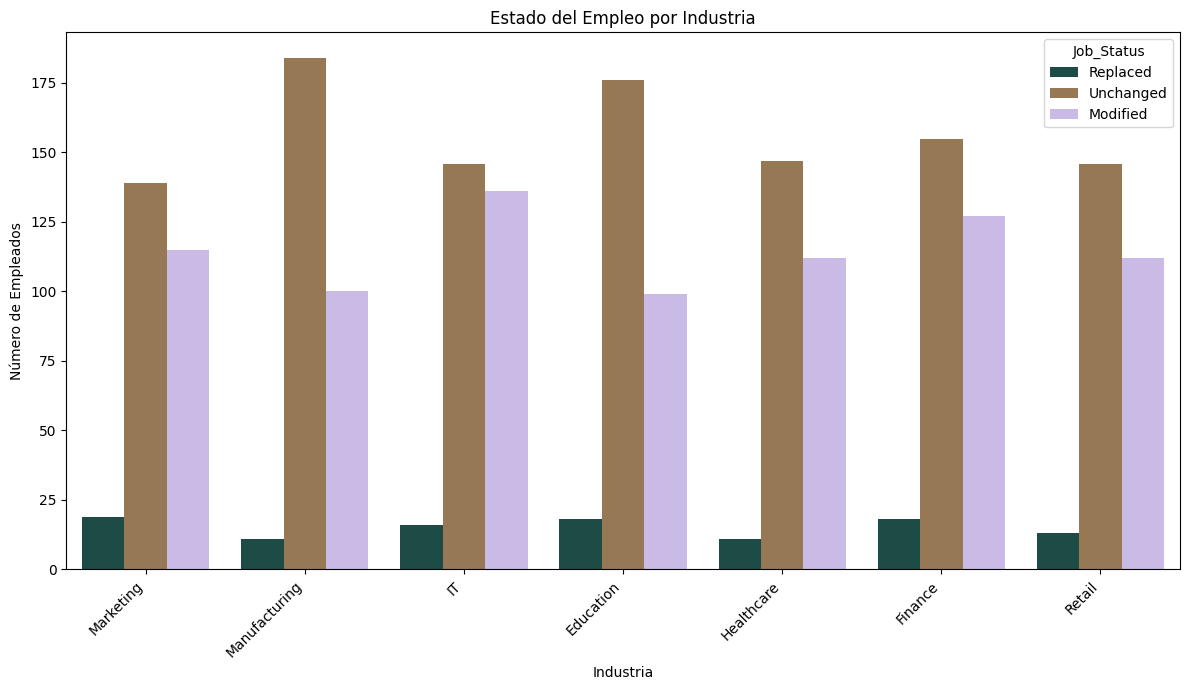

In [29]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Industry', hue='Job_Status', data=df, palette='cubehelix')
plt.title('Estado del Empleo por Industria')
plt.xlabel('Industria')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras agrupadas muestra la distribución de los estados del empleo (Replaced, Modified, Unchanged) a través de las diferentes industrias.
*   Permite identificar qué industrias tienen una mayor proporción de empleos reemplazados, modificados o sin cambios debido a la IA.

#### Distribución del Estado del Empleo por Nivel de Educación

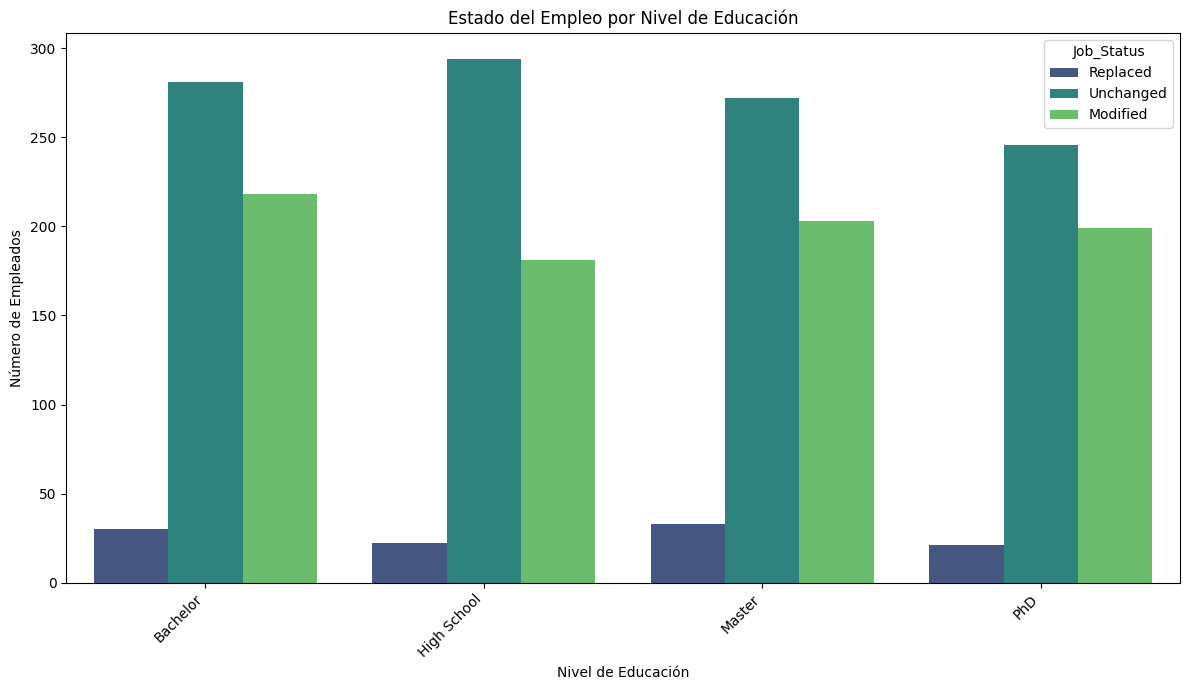

In [30]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Education_Level', hue='Job_Status', data=df, palette='viridis')
plt.title('Estado del Empleo por Nivel de Educación')
plt.xlabel('Nivel de Educación')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Observaciones:
*   Este gráfico de barras agrupadas muestra la distribución de los estados del empleo (Replaced, Modified, Unchanged) según el nivel de educación.
*   Podemos observar si un mayor nivel educativo se correlaciona con una menor probabilidad de que el empleo sea 'Replaced' (reemplazado) o si hay tendencias diferentes.